# HyperKvasir ViT (frozen) + Logistic Regression

Extract CLS embeddings from a frozen ViT backbone and train a shallow classifier as a fast baseline for the 23-class HyperKvasir dataset.

In [1]:
import os
from pathlib import Path
import json
import random
from typing import Tuple

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoImageProcessor, ViTModel

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [2]:
# Paths & config
def find_dataset_root() -> Path:
    start = Path.cwd().resolve()
    for p in [start] + list(start.parents):
        if (p / "0_dataset_prep").exists():
            return p
    raise RuntimeError(f"Could not locate dataset root containing '0_dataset_prep'. cwd={start}")

DATA_ROOT = find_dataset_root()
META_CSV = DATA_ROOT / "0_dataset_prep" / "out" / "metadata" / "metadata_enriched.csv"
LABEL_MAP_CSV = DATA_ROOT / "0_dataset_prep" / "out" / "metadata" / "label_map.csv"
OUT_DIR = DATA_ROOT / "1_ViT" / "out" / "vit_frozen_logreg"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "google/vit-base-patch16-224-in21k"
BATCH_SIZE = 16
NUM_WORKERS = 0  # set >0 if you want multiprocessing loaders
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("Data root:", DATA_ROOT)
print("Output dir:", OUT_DIR)


Device: cuda
Data root: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/HyperKvasir
Output dir: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/HyperKvasir/1_ViT/out/vit_frozen_logreg


In [3]:
# Load metadata
meta = pd.read_csv(META_CSV)
print(meta.head())
print("Rows:", len(meta))

# Normalize image paths to absolute (base is 0_dataset_prep)
images_base = DATA_ROOT / "0_dataset_prep"

def to_abs(p):
    p = Path(p)
    if p.is_absolute():
        return p
    # CSV stores paths like "out/images/..." relative to 0_dataset_prep
    return (images_base / p).resolve()

meta["image_path"] = meta["image_path"].apply(lambda p: str(to_abs(p)))

# Label map
if LABEL_MAP_CSV.exists():
    label_map = pd.read_csv(LABEL_MAP_CSV)
    id_to_name = dict(zip(label_map.label_id, label_map.label_name))
else:
    id_to_name = {i: name for i, name in enumerate(sorted(meta.label_name.unique()))}

name_to_id = {v: k for k, v in id_to_name.items()}
meta["label_id"] = meta["label_name"].map(name_to_id)

# Keep only rows with existing images
meta = meta[meta["image_path"].apply(lambda p: Path(p).exists())].reset_index(drop=True)
print("After dropping missing images:", meta.shape)
print("Splits:")
print(meta["split"].value_counts())


   split        img_id                         image_path  label_id  \
0  train  train_000000  out/images/train/train_000000.jpg         0   
1  train  train_000001  out/images/train/train_000001.jpg         0   
2  train  train_000002  out/images/train/train_000002.jpg         0   
3  train  train_000003  out/images/train/train_000003.jpg         0   
4  train  train_000004  out/images/train/train_000004.jpg         0   

  label_name  orig_height  orig_width  
0   barretts         1013        1221  
1   barretts          524         613  
2   barretts         1020        1221  
3   barretts         1012        1221  
4   barretts         1071        1349  
Rows: 10662


After dropping missing images: (10662, 7)
Splits:
split
train         8528
validation    1069
test          1065
Name: count, dtype: int64


In [4]:
# Dataset + dataloader
class ImageDS(Dataset):
    def __init__(self, df: pd.DataFrame, processor):
        self.paths = df["image_path"].tolist()
        self.labels = df["label_id"].astype(int).tolist()
        self.processor = processor
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        inp = self.processor(images=img, return_tensors="pt")
        pixel_values = inp["pixel_values"][0]
        label = self.labels[idx]
        return pixel_values, label

def collate_fn(batch):
    pixels = torch.stack([b[0] for b in batch], dim=0)
    labels = torch.tensor([b[1] for b in batch], dtype=torch.long)
    return pixels, labels


In [5]:
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
vit = ViTModel.from_pretrained(MODEL_NAME).to(DEVICE)
vit.eval()

print("Loaded ViT")


/home/aristotle/anaconda3/lib/python3.12/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loaded ViT


In [6]:
def extract_split(df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray]:
    ds = ImageDS(df, processor)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)
    feats = []
    labels = []
    with torch.no_grad():
        for pixels, y in tqdm(dl, desc="embed", leave=False):
            pixels = pixels.to(DEVICE)
            out = vit(pixels).last_hidden_state[:, 0, :]  # CLS token
            feats.append(out.cpu().numpy())
            labels.append(y.numpy())
    return np.concatenate(feats, axis=0), np.concatenate(labels, axis=0)


In [7]:
# Extract embeddings per split
train_df = meta[meta["split"] == "train"].reset_index(drop=True)
val_df   = meta[meta["split"] == "validation"].reset_index(drop=True)
test_df  = meta[meta["split"] == "test"].reset_index(drop=True)

print({"train": len(train_df), "val": len(val_df), "test": len(test_df)})

train_X, train_y = extract_split(train_df)
val_X,   val_y   = extract_split(val_df)
test_X,  test_y  = extract_split(test_df)


{'train': 8528, 'val': 1069, 'test': 1065}


embed:   0%|          | 0/533 [00:00<?, ?it/s]

embed:   0%|          | 0/67 [00:00<?, ?it/s]

embed:   0%|          | 0/67 [00:00<?, ?it/s]

In [8]:
# Train logistic regression on frozen embeddings
scaler = StandardScaler()
train_Xs = scaler.fit_transform(train_X)
val_Xs   = scaler.transform(val_X)
test_Xs  = scaler.transform(test_X)

clf = LogisticRegression(
    max_iter=2000,
    multi_class="multinomial",
    class_weight="balanced",
    n_jobs=-1,
)
clf.fit(train_Xs, train_y)

val_pred  = clf.predict(val_Xs)
test_pred = clf.predict(test_Xs)


/home/aristotle/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [9]:
# Summarize metrics
def summarize(split_name, y_true, y_pred):
    labels = sorted(id_to_name.keys())
    target_names = [id_to_name[i] for i in labels]
    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    return report, cm

val_report, val_cm = summarize("val", val_y, val_pred)
test_report, test_cm = summarize("test", test_y, test_pred)

print("Val accuracy:", val_report["accuracy"])
print("Test accuracy:", test_report["accuracy"])


Val accuracy: 0.8699719363891487
Test accuracy: 0.8619718309859155


In [10]:
# Save metrics
OUT_DIR.mkdir(parents=True, exist_ok=True)

with open(OUT_DIR / "metrics_val.json", "w") as f:
    json.dump(val_report, f, indent=2)
with open(OUT_DIR / "metrics_test.json", "w") as f:
    json.dump(test_report, f, indent=2)

pd.DataFrame(val_report).T.to_csv(OUT_DIR / "metrics_val.csv")
pd.DataFrame(test_report).T.to_csv(OUT_DIR / "metrics_test.csv")

np.save(OUT_DIR / "confusion_val.npy", val_cm)
np.save(OUT_DIR / "confusion_test.npy", test_cm)

pred_df = pd.DataFrame({
    "split": ["val"] * len(val_y) + ["test"] * len(test_y),
    "y_true": np.concatenate([val_y, test_y]),
    "y_pred": np.concatenate([val_pred, test_pred]),
})
pred_df.to_csv(OUT_DIR / "predictions_val_test.csv", index=False)

print("Saved metrics to", OUT_DIR)


Saved metrics to /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/HyperKvasir/1_ViT/out/vit_frozen_logreg


Saved confusion matrix to /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/HyperKvasir/1_ViT/out/vit_frozen_logreg/confusion_test.png


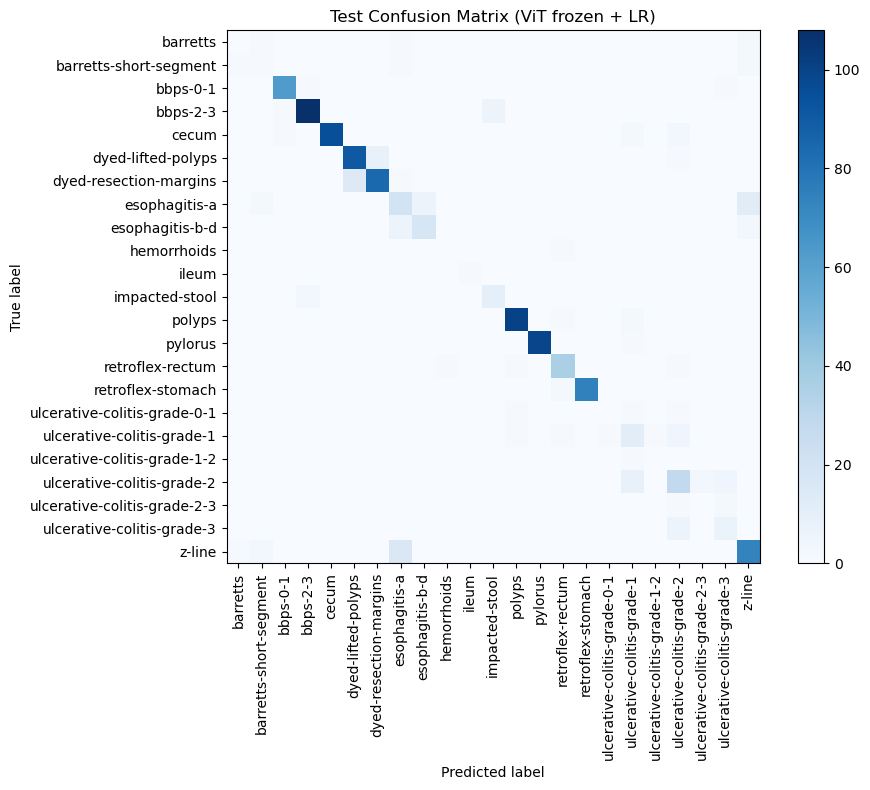

In [11]:
# Plot confusion matrix for test split
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=test_cm, display_labels=[id_to_name[i] for i in sorted(id_to_name)])
disp.plot(include_values=False, cmap="Blues", ax=ax, xticks_rotation=90)
plt.title("Test Confusion Matrix (ViT frozen + LR)")
plt.tight_layout()
fig_path = OUT_DIR / "confusion_test.png"
plt.savefig(fig_path, dpi=200)
print("Saved confusion matrix to", fig_path)
